# Eksplorasi Data Iklim Harian Dramaga, Bogor (1980–2024)

1. Loading & inspeksi awal data
2. Statistik deskriptif tiap variabel
3. Deteksi missing value & outlier
4. Time series suhu & curah hujan (tren jangka panjang)
5. Pola musiman per bulan (boxplot bulanan)
6. Heatmap korelasi antar variabel
7. Visualisasi pola El Niño (tahun anomali: 1997, 2015, 2023)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = '../data/dataset_iklim_dramaga_1980_2024_completed.csv'

---
## 1. Loading & Inspeksi Awal

In [2]:
df_raw = pd.read_csv(DATA_PATH)

# Kolom 'date' dari ERA5 dalam UTC (format: 1979-12-31 17:00:00+00:00)
# UTC+17:00 = pukul 00:00 WIB hari berikutnya → shift ke tanggal lokal
df_raw['date'] = pd.to_datetime(df_raw['date'], utc=True)
df_raw['date'] = df_raw['date'].dt.tz_convert('Asia/Jakarta').dt.normalize()
df_raw['date'] = df_raw['date'].dt.tz_localize(None)  # buang timezone info

df = df_raw.set_index('date').sort_index()

print(f'Shape   : {df.shape}')
print(f'Rentang : {df.index.min().date()} s/d {df.index.max().date()}')
print(f'Kolom   : {list(df.columns)}')
df.head()

Shape   : (16437, 13)
Rentang : 1980-01-01 s/d 2024-12-31
Kolom   : ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'rain_sum', 'et0_fao_evapotranspiration', 'shortwave_radiation_sum', 'relative_humidity_2m_mean', 'vapor_pressure_deficit_max', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'soil_temperature_0_to_7cm_mean', 'soil_moisture_0_to_7cm_mean']


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,et0_fao_evapotranspiration,shortwave_radiation_sum,relative_humidity_2m_mean,vapor_pressure_deficit_max,wind_speed_10m_max,wind_direction_10m_dominant,soil_temperature_0_to_7cm_mean,soil_moisture_0_to_7cm_mean
date,,,,,,,,,,,,,
1980-01-01,24.716002,28.466,22.616,8.000000,8.000000,3.168779,16.20,89.546730,0.923710,11.165805,252.63809,26.057665,0.485583
1980-01-02,24.116000,26.166,22.566,11.200002,11.200002,2.161778,10.77,91.676636,0.584770,9.720000,264.12490,25.268084,0.488250
1980-01-03,24.316000,27.616,22.266,13.100000,13.100000,2.639856,13.11,90.786460,0.727327,7.491114,271.85504,25.401413,0.481583
1980-01-04,24.511835,28.916,21.816,12.499999,12.499999,3.372404,17.21,90.920800,1.122690,8.654986,281.42114,25.870169,0.462625
1980-01-05,24.568085,28.966,21.916,9.299999,9.299999,3.212871,16.26,89.683920,1.177142,10.105681,235.27528,25.841002,0.463958


In [3]:
df.dtypes

temperature_2m_mean               float64
temperature_2m_max                float64
temperature_2m_min                float64
precipitation_sum                 float64
rain_sum                          float64
et0_fao_evapotranspiration        float64
shortwave_radiation_sum           float64
relative_humidity_2m_mean         float64
vapor_pressure_deficit_max        float64
wind_speed_10m_max                float64
wind_direction_10m_dominant       float64
soil_temperature_0_to_7cm_mean    float64
soil_moisture_0_to_7cm_mean       float64
dtype: object

---
## 2. Statistik Deskriptif

In [4]:
desc = df.describe().T
desc['skewness'] = df.apply(lambda c: c.skew())
desc['kurtosis'] = df.apply(lambda c: c.kurtosis())
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
temperature_2m_mean,16437.0,25.3046,0.8172,22.0702,24.7708,25.2535,25.7764,29.4417,0.4689,0.7791
temperature_2m_max,16437.0,29.4577,1.5278,23.6660,28.6160,29.4660,30.2160,36.4500,0.2822,1.6702
temperature_2m_min,16437.0,22.1253,0.8516,15.7660,21.6660,22.2160,22.7000,25.0000,-0.7043,1.6140
precipitation_sum,16437.0,7.5959,8.4564,0.0000,1.3000,5.1000,11.3000,127.4000,2.6154,15.1758
rain_sum,16437.0,7.5959,8.4564,0.0000,1.3000,5.1000,11.3000,127.4000,2.6154,15.1758
et0_fao_evapotranspiration,16437.0,3.5991,0.8273,0.6031,3.1202,3.6299,4.1258,6.8660,-0.1908,0.4775
shortwave_radiation_sum,16437.0,17.6904,3.8120,2.2300,15.6200,18.0900,20.2600,28.6200,-0.6252,0.5798
relative_humidity_2m_mean,16437.0,85.4388,6.6900,48.6007,82.6037,87.3028,90.1432,96.7115,-1.4605,2.3379
vapor_pressure_deficit_max,16437.0,1.3568,0.5793,0.1635,0.9891,1.2361,1.5665,4.9740,1.5659,3.5503
wind_speed_10m_max,16437.0,8.9172,2.6511,3.3190,7.1458,8.3501,10.0414,26.2899,1.5555,3.8603


### Distribusi tiap variabel

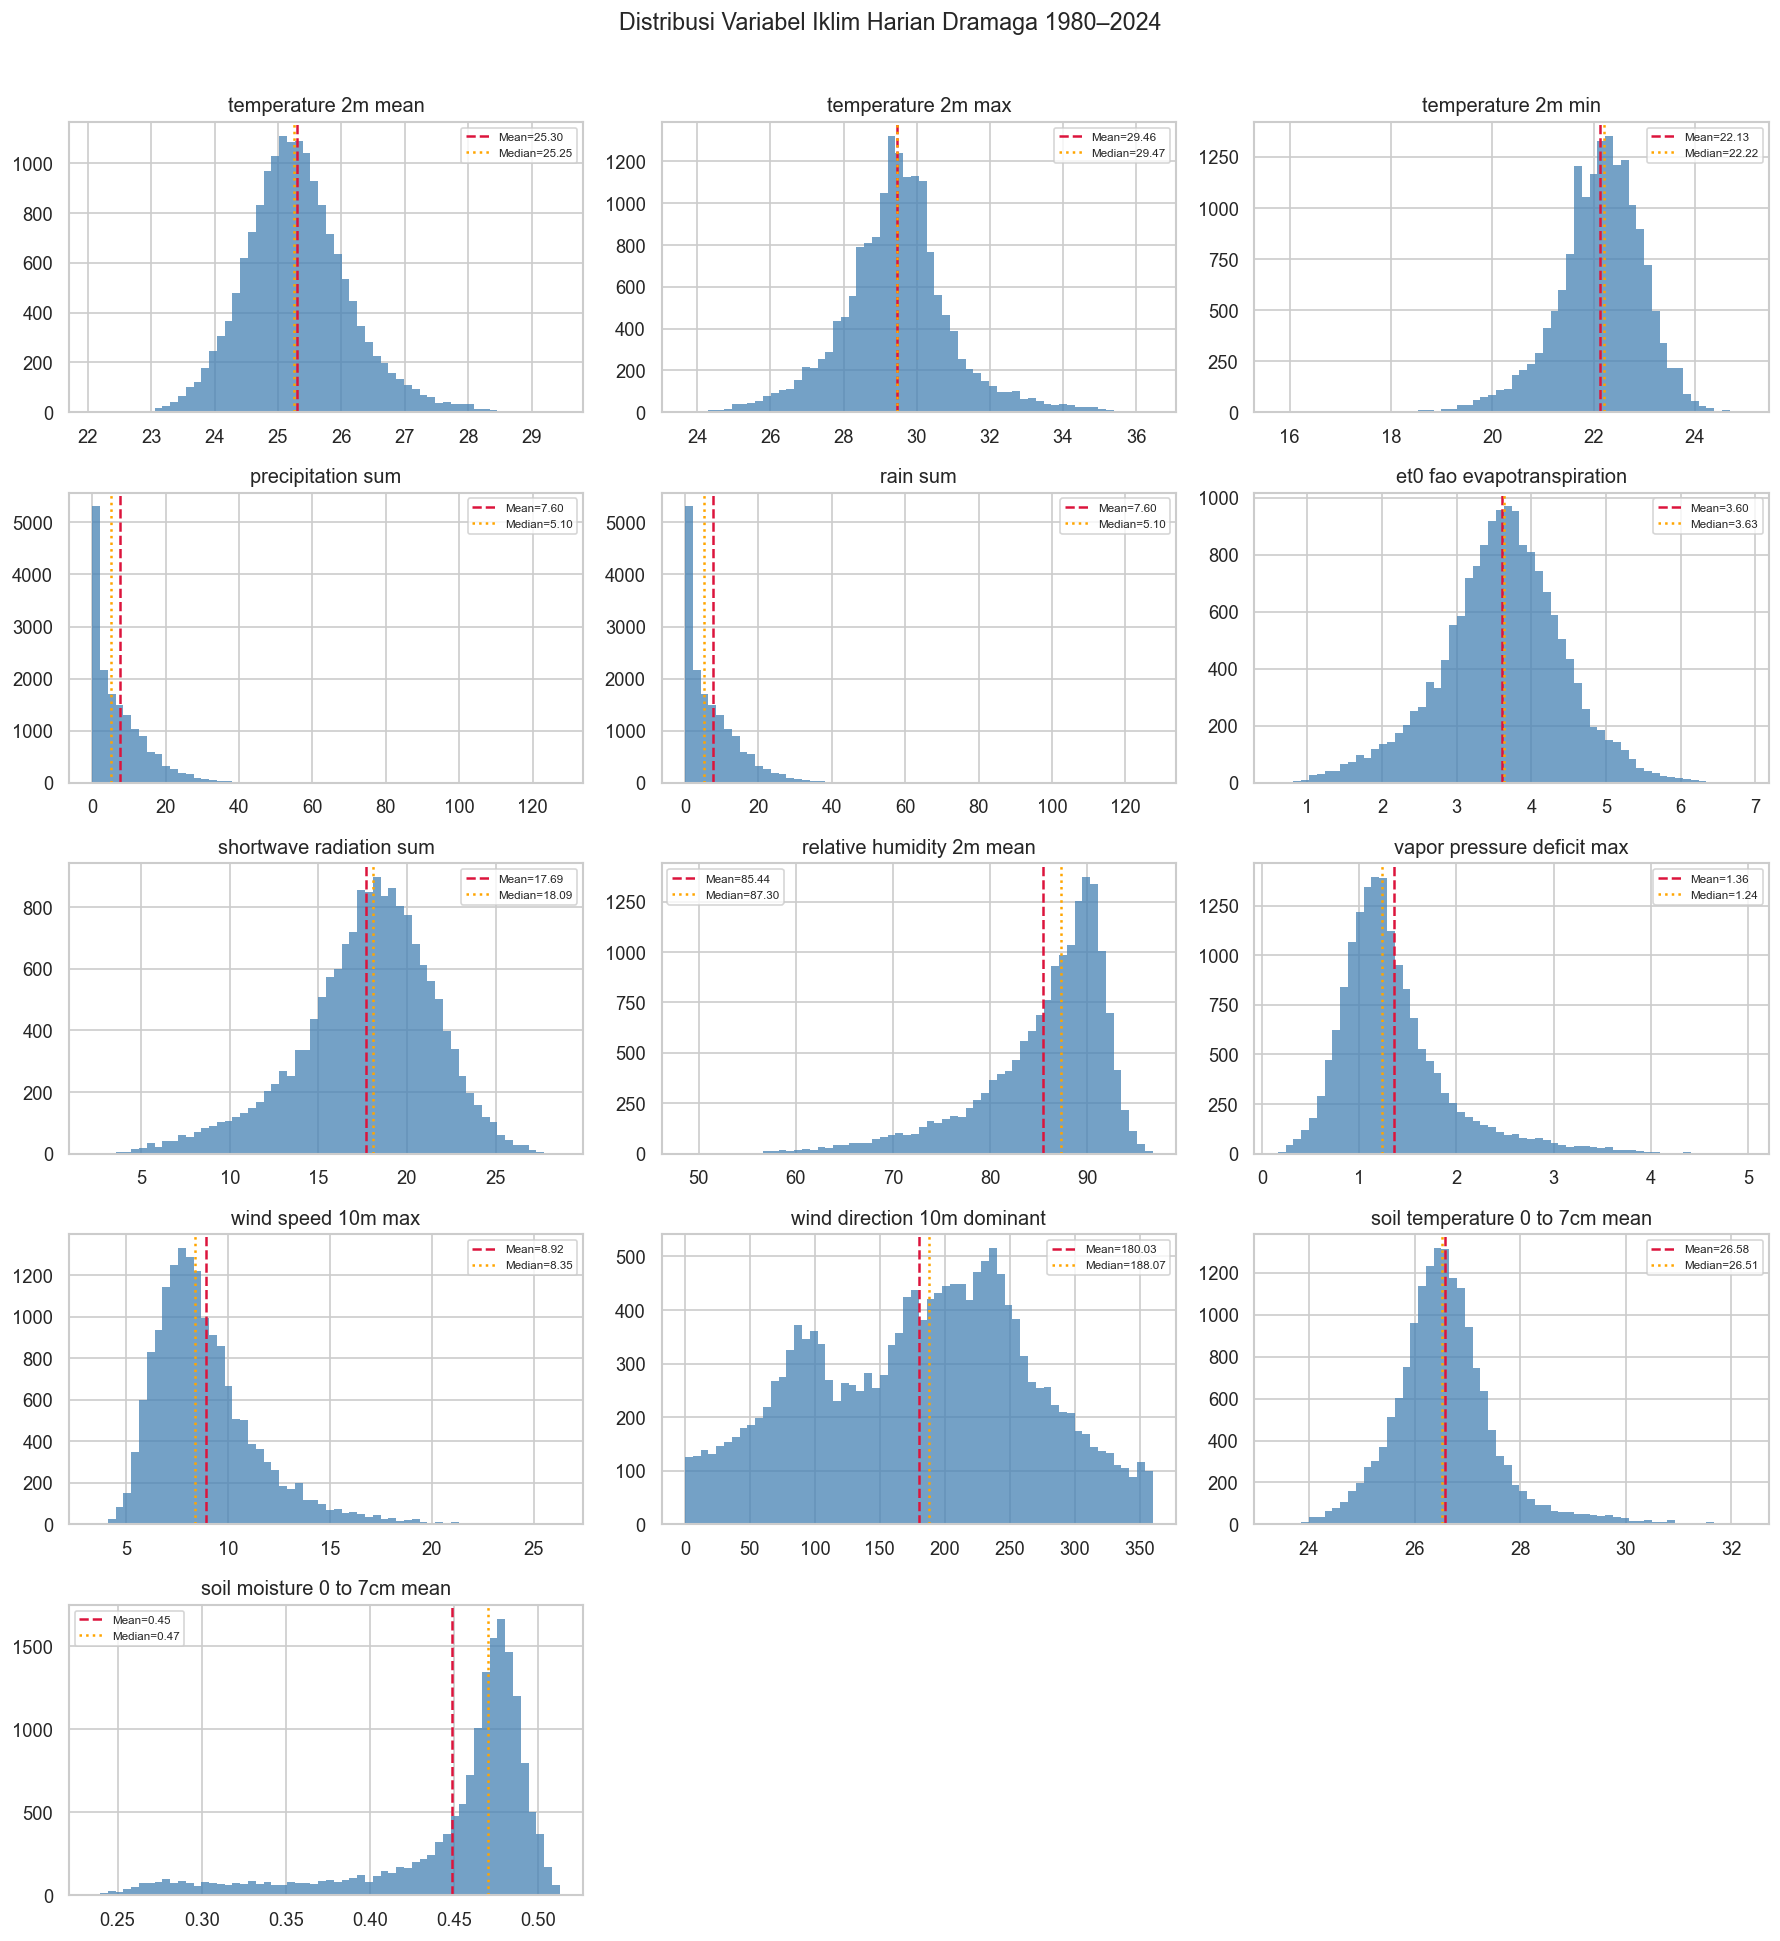

In [5]:
cols = df.columns.tolist()
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    ax.axvline(data.mean(), color='crimson', lw=1.5, linestyle='--', label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='orange', lw=1.5, linestyle=':', label=f'Median={data.median():.2f}')
    ax.set_title(col.replace('_', ' '))
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Variabel Iklim Harian Dramaga 1980–2024', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Deteksi Missing Value & Outlier

In [6]:
# --- Missing values ---
missing = df.isnull().sum().rename('null_count')
missing_pct = (missing / len(df) * 100).rename('null_pct')
mv_df = pd.concat([missing, missing_pct], axis=1)
print('=== Missing Values ===')
print(mv_df[mv_df['null_count'] > 0] if mv_df['null_count'].any() else 'Tidak ada missing value ✓')

=== Missing Values ===
Tidak ada missing value ✓


In [7]:
# --- Gap tanggal (hari yang hilang) ---
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
missing_dates = full_idx.difference(df.index)
print(f'Jumlah hari dalam rentang : {len(full_idx)}')
print(f'Jumlah baris data         : {len(df)}')
print(f'Tanggal hilang            : {len(missing_dates)}')
if len(missing_dates):
    print(missing_dates)

Jumlah hari dalam rentang : 16437
Jumlah baris data         : 16437
Tanggal hilang            : 0


In [8]:
# --- Outlier via IQR ---
outlier_summary = {}
for col in cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {
        'IQR': round(iqr, 3),
        'lower_fence': round(lo, 3),
        'upper_fence': round(hi, 3),
        'n_outlier': n_out,
        'outlier_pct': round(n_out / len(df) * 100, 2),
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df.sort_values('n_outlier', ascending=False)

,IQR,lower_fence,upper_fence,n_outlier,outlier_pct
soil_moisture_0_to_7cm_mean,0.039,0.383,0.541,2080.0,12.65
vapor_pressure_deficit_max,0.577,0.123,2.433,964.0,5.86
temperature_2m_max,1.600,26.216,32.616,907.0,5.52
relative_humidity_2m_mean,7.539,71.295,101.452,821.0,4.99
soil_temperature_0_to_7cm_mean,1.021,24.481,28.564,809.0,4.92
wind_speed_10m_max,2.896,2.802,14.385,730.0,4.44
precipitation_sum,10.000,-13.700,26.300,534.0,3.25
rain_sum,10.000,-13.700,26.300,534.0,3.25
shortwave_radiation_sum,4.640,8.660,27.220,434.0,2.64
temperature_2m_min,1.034,20.115,24.251,404.0,2.46


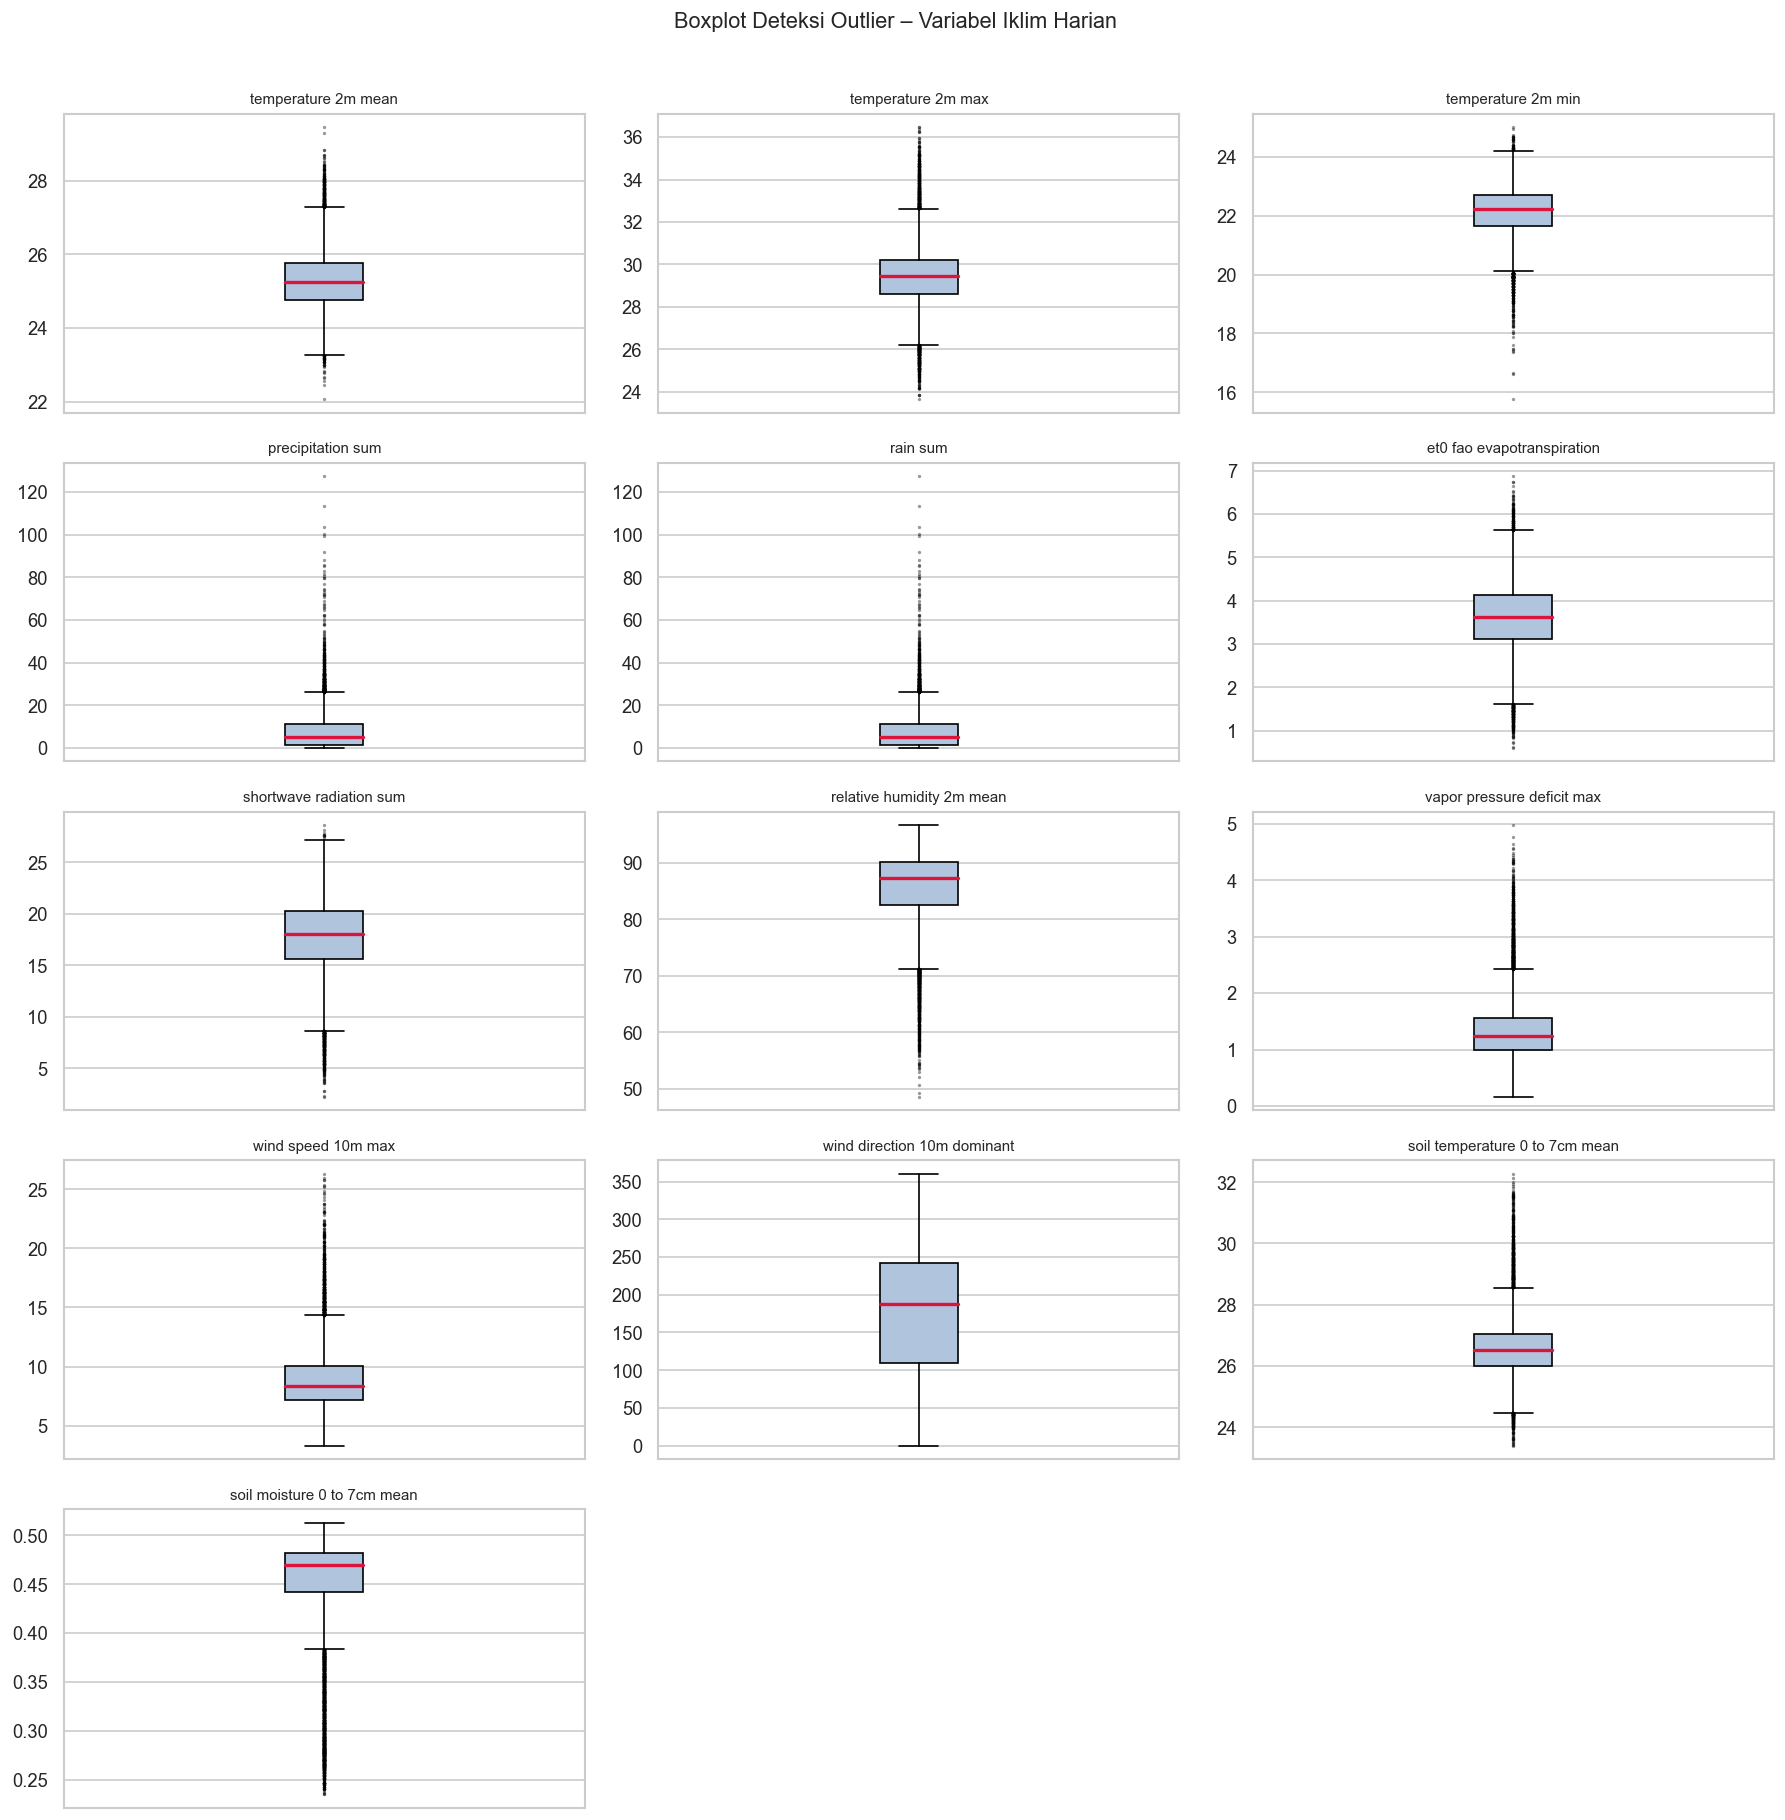

In [9]:
# Boxplot outlier semua variabel
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'),
                    medianprops=dict(color='crimson', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.4))
    axes[i].set_title(col.replace('_', ' '), fontsize=9)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot Deteksi Outlier – Variabel Iklim Harian', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Time Series Jangka Panjang (1980–2024)

In [10]:
# Agregasi bulanan
monthly = df.resample('ME').agg({
    'temperature_2m_mean': 'mean',
    'temperature_2m_max': 'mean',
    'temperature_2m_min': 'mean',
    'precipitation_sum': 'sum',
    'et0_fao_evapotranspiration': 'sum',
    'relative_humidity_2m_mean': 'mean',
    'soil_moisture_0_to_7cm_mean': 'mean',
})

# Agregasi tahunan
annual = df.resample('YE').agg({
    'temperature_2m_mean': 'mean',
    'precipitation_sum': 'sum',
    'et0_fao_evapotranspiration': 'sum',
    'relative_humidity_2m_mean': 'mean',
    'soil_moisture_0_to_7cm_mean': 'mean',
})

/tmp/ipykernel_940126/1189238825.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


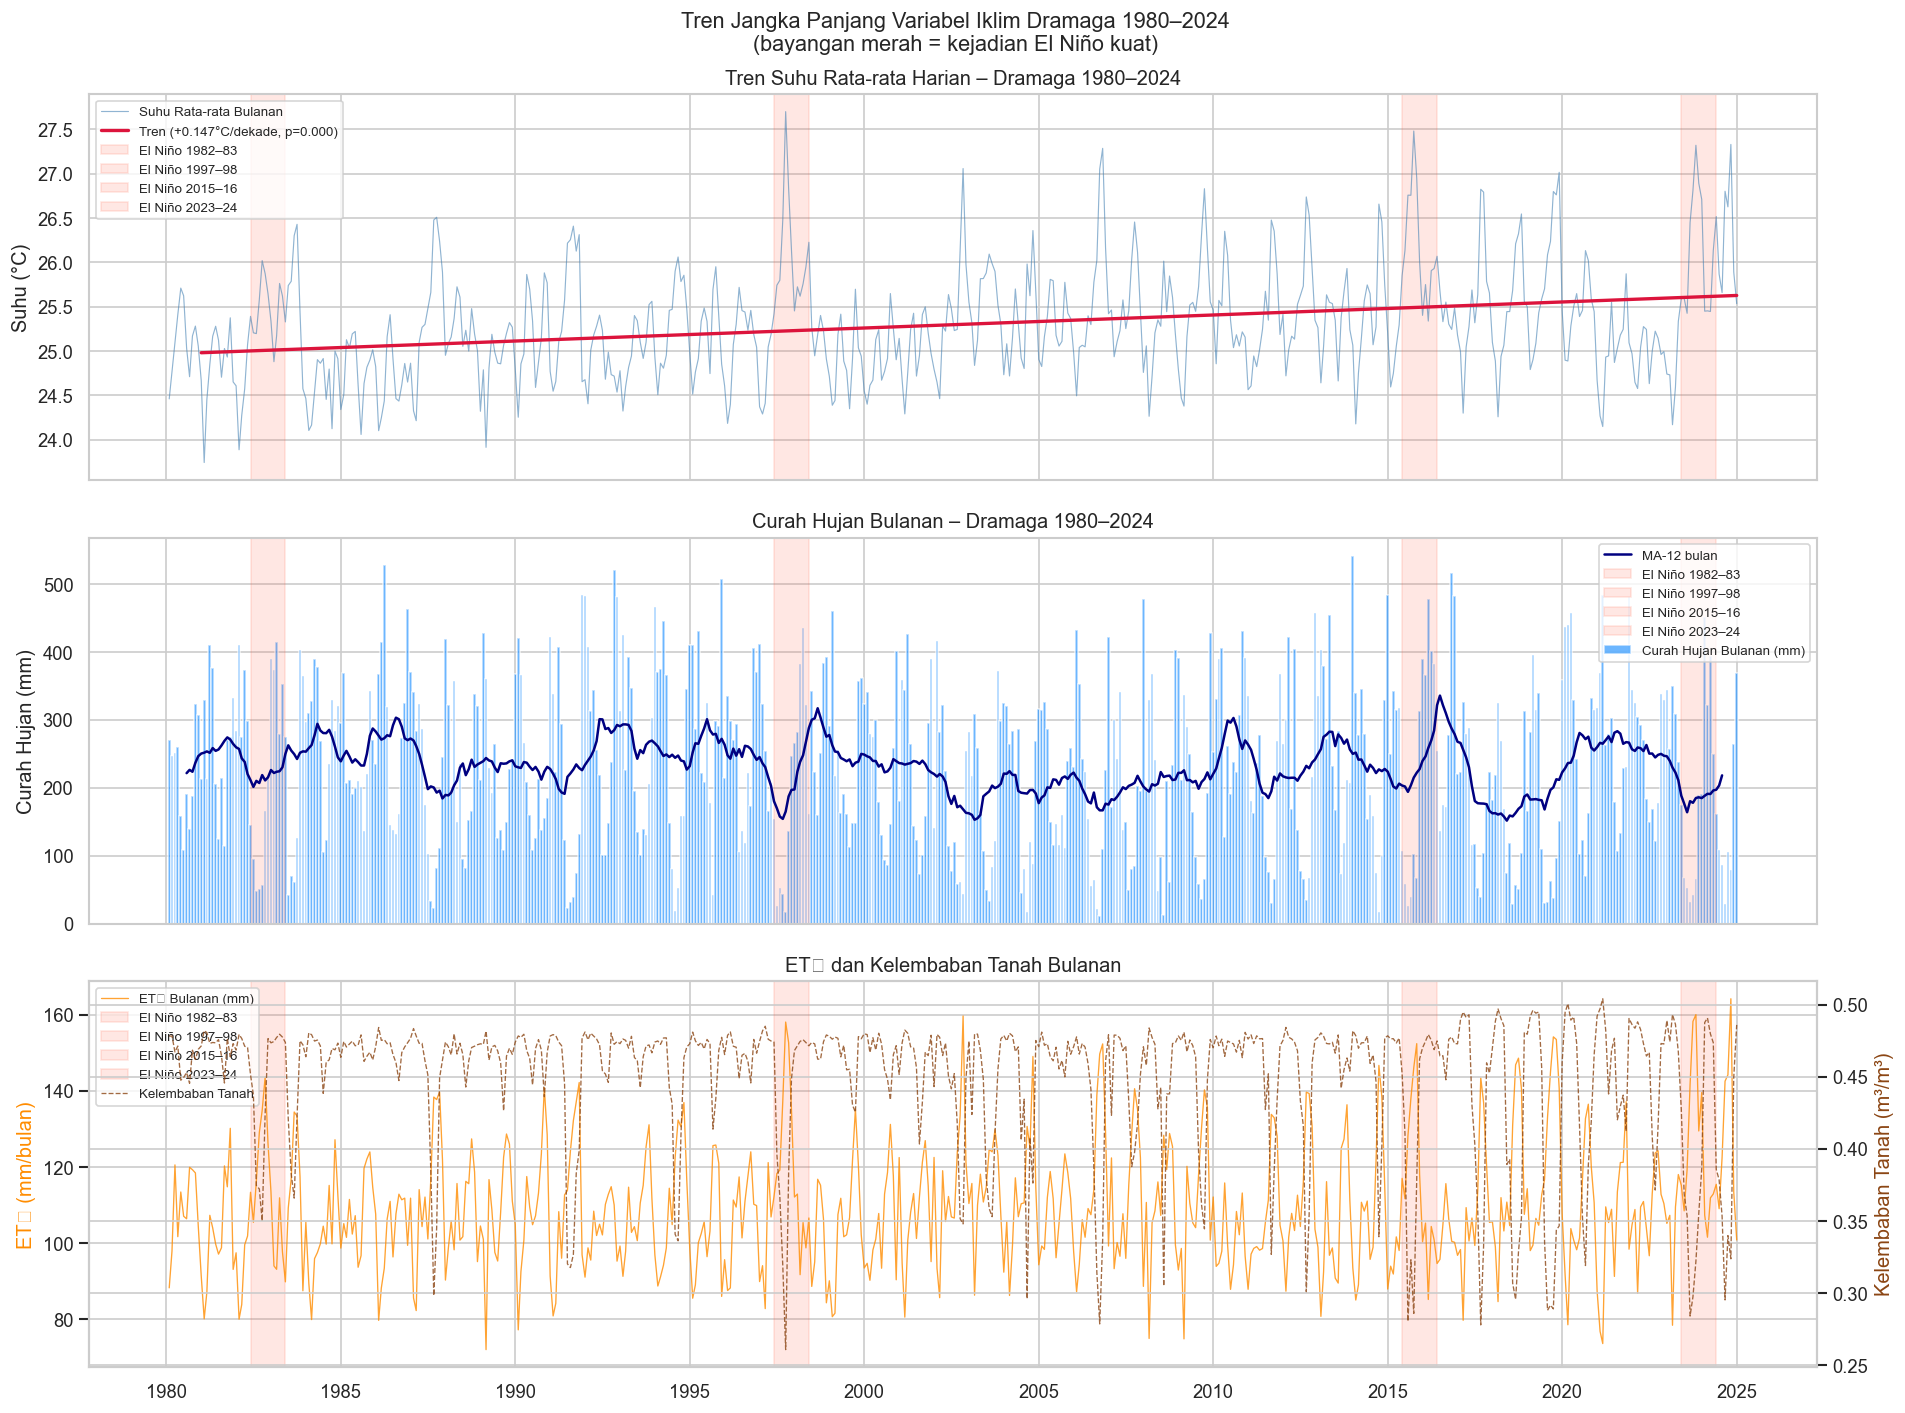

Tren suhu: 0.1467°C per dekade


In [11]:
# Highlight El Niño
ENSO_EVENTS = [
    (1982, 1983, 'El Niño 1982–83'),
    (1997, 1998, 'El Niño 1997–98'),
    (2015, 2016, 'El Niño 2015–16'),
    (2023, 2024, 'El Niño 2023–24'),
]

def shade_enso(ax, alpha=0.15):
    for y1, y2, label in ENSO_EVENTS:
        ax.axvspan(pd.Timestamp(f'{y1}-06-01'), pd.Timestamp(f'{y2}-05-31'),
                   color='tomato', alpha=alpha, label=label)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# --- Suhu ---
ax = axes[0]
ax.plot(monthly.index, monthly['temperature_2m_mean'], color='steelblue', lw=0.7, alpha=0.6, label='Suhu Rata-rata Bulanan')
# Tren linear tahunan
x_num = (annual.index.year - annual.index.year.min()).values
slope, intercept, r, p, _ = stats.linregress(x_num, annual['temperature_2m_mean'])
trend_y = annual.index
ax.plot(trend_y, intercept + slope * x_num, color='crimson', lw=2, label=f'Tren (+{slope*10:.3f}°C/dekade, p={p:.3f})')
shade_enso(ax)
ax.set_ylabel('Suhu (°C)')
ax.set_title('Tren Suhu Rata-rata Harian – Dramaga 1980–2024')
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=8, loc='upper left')

# --- Curah Hujan Bulanan ---
ax = axes[1]
ax.bar(monthly.index, monthly['precipitation_sum'], width=28, color='dodgerblue', alpha=0.65, label='Curah Hujan Bulanan (mm)')
# Rolling 12 bulan
ax.plot(monthly.index, monthly['precipitation_sum'].rolling(12, center=True).mean(),
        color='navy', lw=1.5, label='MA-12 bulan')
shade_enso(ax)
ax.set_ylabel('Curah Hujan (mm)')
ax.set_title('Curah Hujan Bulanan – Dramaga 1980–2024')
ax.legend(fontsize=8, loc='upper right')

# --- ET0 & Soil Moisture ---
ax = axes[2]
ax2r = ax.twinx()
ax.plot(monthly.index, monthly['et0_fao_evapotranspiration'], color='darkorange', lw=0.8, alpha=0.8, label='ET₀ Bulanan (mm)')
ax2r.plot(monthly.index, monthly['soil_moisture_0_to_7cm_mean'], color='saddlebrown', lw=0.8, alpha=0.8, linestyle='--', label='Kelembaban Tanah')
shade_enso(ax)
ax.set_ylabel('ET₀ (mm/bulan)', color='darkorange')
ax2r.set_ylabel('Kelembaban Tanah (m³/m³)', color='saddlebrown')
ax.set_title('ET₀ dan Kelembaban Tanah Bulanan')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=0)

fig.suptitle('Tren Jangka Panjang Variabel Iklim Dramaga 1980–2024\n(bayangan merah = kejadian El Niño kuat)', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Tren suhu: {slope*10:.4f}°C per dekade')

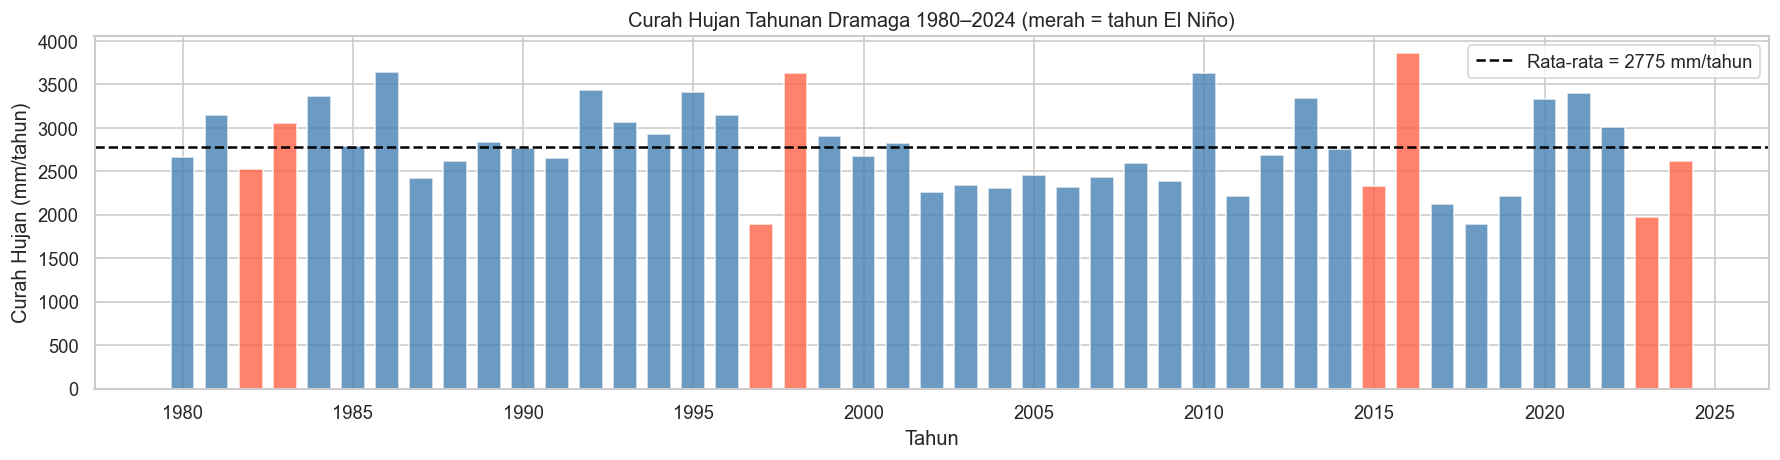

In [12]:
# Curah hujan tahunan
fig, ax = plt.subplots(figsize=(15, 4))
colors = ['tomato' if y in [1982,1983,1997,1998,2015,2016,2023,2024] else 'steelblue'
          for y in annual.index.year]
ax.bar(annual.index.year, annual['precipitation_sum'], color=colors, alpha=0.8, width=0.7)
ax.axhline(annual['precipitation_sum'].mean(), color='black', lw=1.5, linestyle='--',
           label=f"Rata-rata = {annual['precipitation_sum'].mean():.0f} mm/tahun")
ax.set_xlabel('Tahun')
ax.set_ylabel('Curah Hujan (mm/tahun)')
ax.set_title('Curah Hujan Tahunan Dramaga 1980–2024 (merah = tahun El Niño)')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

---
## 5. Pola Musiman per Bulan

/tmp/ipykernel_940126/436398328.py:53: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


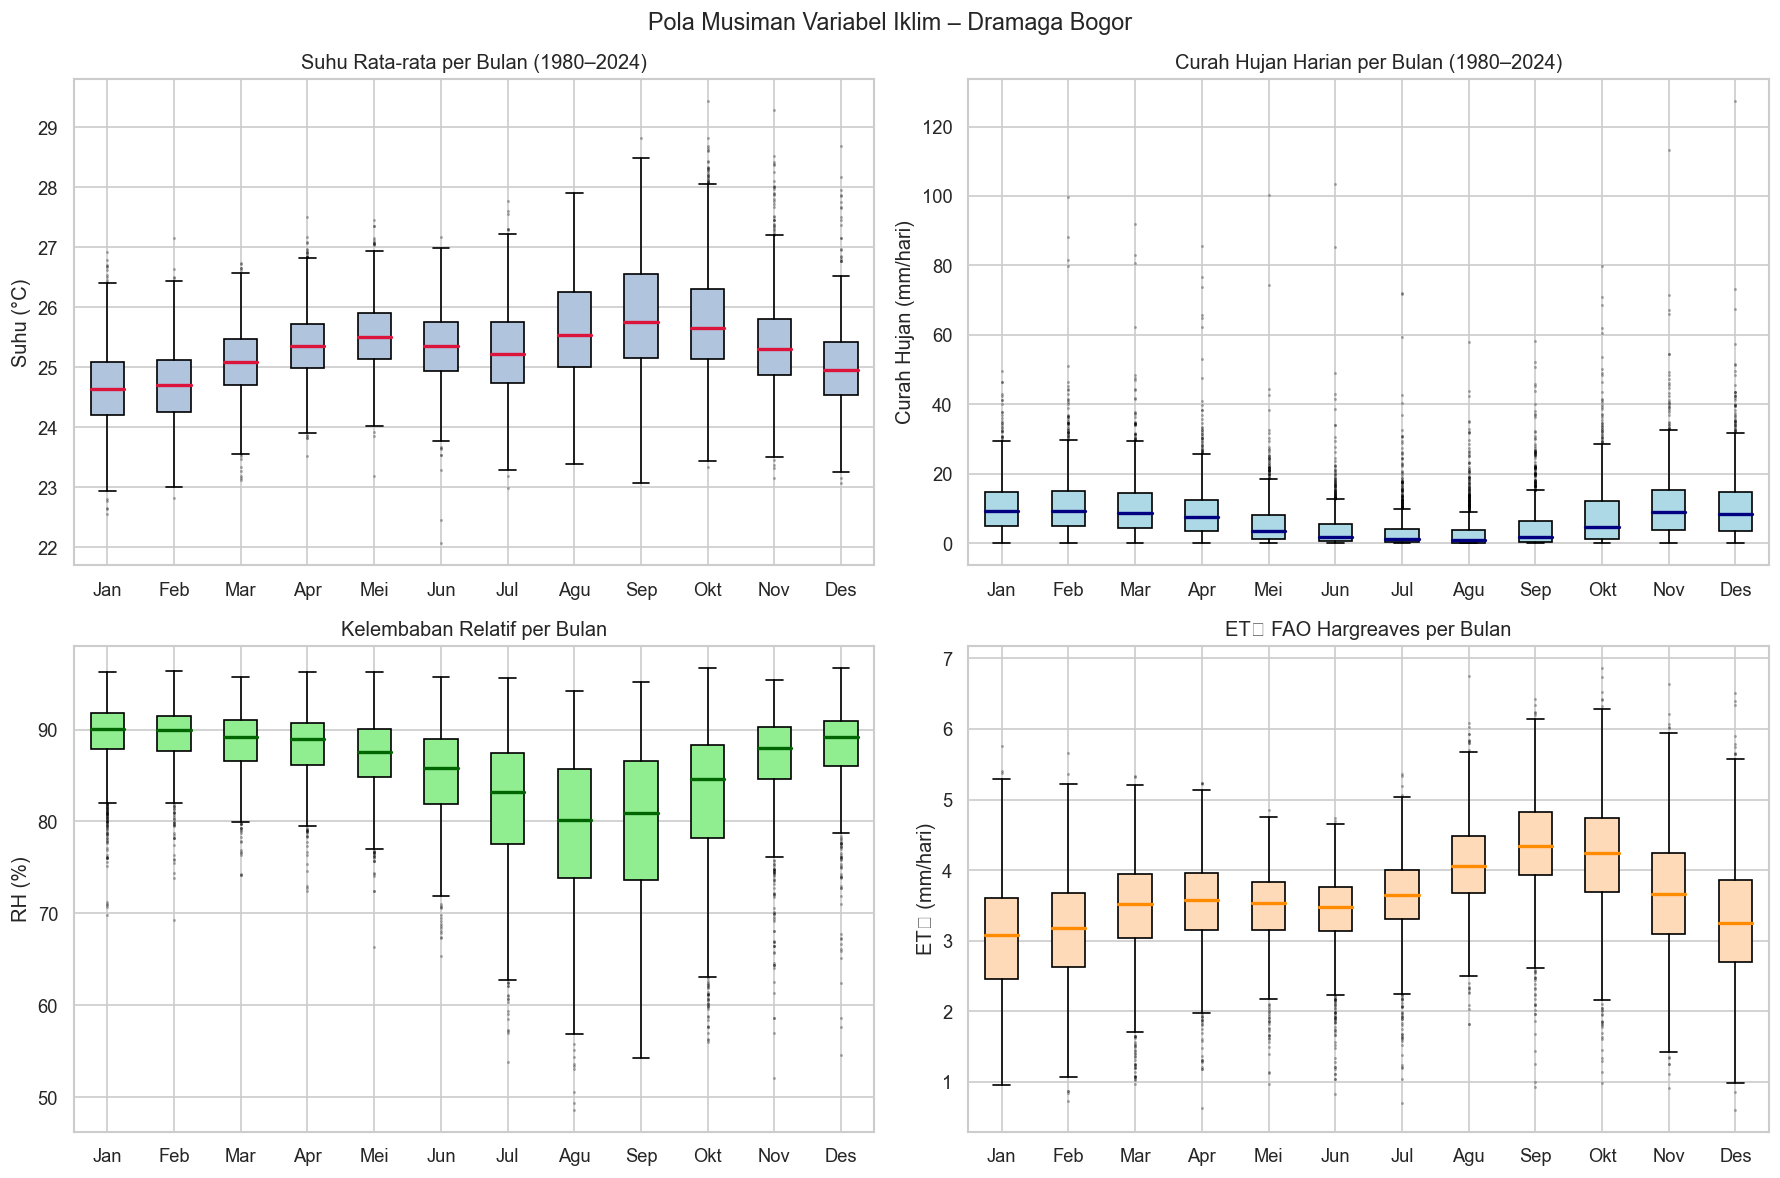

In [13]:
df['month'] = df.index.month
df['year']  = df.index.year

month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Suhu
ax = axes[0, 0]
data_month = [df[df['month'] == m]['temperature_2m_mean'].dropna().values for m in range(1, 13)]
bp = ax.boxplot(data_month, labels=month_labels, patch_artist=True,
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='.', markersize=1.5, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
ax.set_title('Suhu Rata-rata per Bulan (1980–2024)')
ax.set_ylabel('Suhu (°C)')

# Curah Hujan
ax = axes[0, 1]
data_month = [df[df['month'] == m]['precipitation_sum'].dropna().values for m in range(1, 13)]
bp = ax.boxplot(data_month, labels=month_labels, patch_artist=True,
                medianprops=dict(color='navy', linewidth=2),
                flierprops=dict(marker='.', markersize=1.5, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_title('Curah Hujan Harian per Bulan (1980–2024)')
ax.set_ylabel('Curah Hujan (mm/hari)')

# Kelembaban relatif
ax = axes[1, 0]
data_month = [df[df['month'] == m]['relative_humidity_2m_mean'].dropna().values for m in range(1, 13)]
bp = ax.boxplot(data_month, labels=month_labels, patch_artist=True,
                medianprops=dict(color='darkgreen', linewidth=2),
                flierprops=dict(marker='.', markersize=1.5, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax.set_title('Kelembaban Relatif per Bulan')
ax.set_ylabel('RH (%)')

# ET0
ax = axes[1, 1]
data_month = [df[df['month'] == m]['et0_fao_evapotranspiration'].dropna().values for m in range(1, 13)]
bp = ax.boxplot(data_month, labels=month_labels, patch_artist=True,
                medianprops=dict(color='darkorange', linewidth=2),
                flierprops=dict(marker='.', markersize=1.5, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('peachpuff')
ax.set_title('ET₀ FAO Hargreaves per Bulan')
ax.set_ylabel('ET₀ (mm/hari)')

fig.suptitle('Pola Musiman Variabel Iklim – Dramaga Bogor', fontsize=14)
plt.tight_layout()
plt.show()

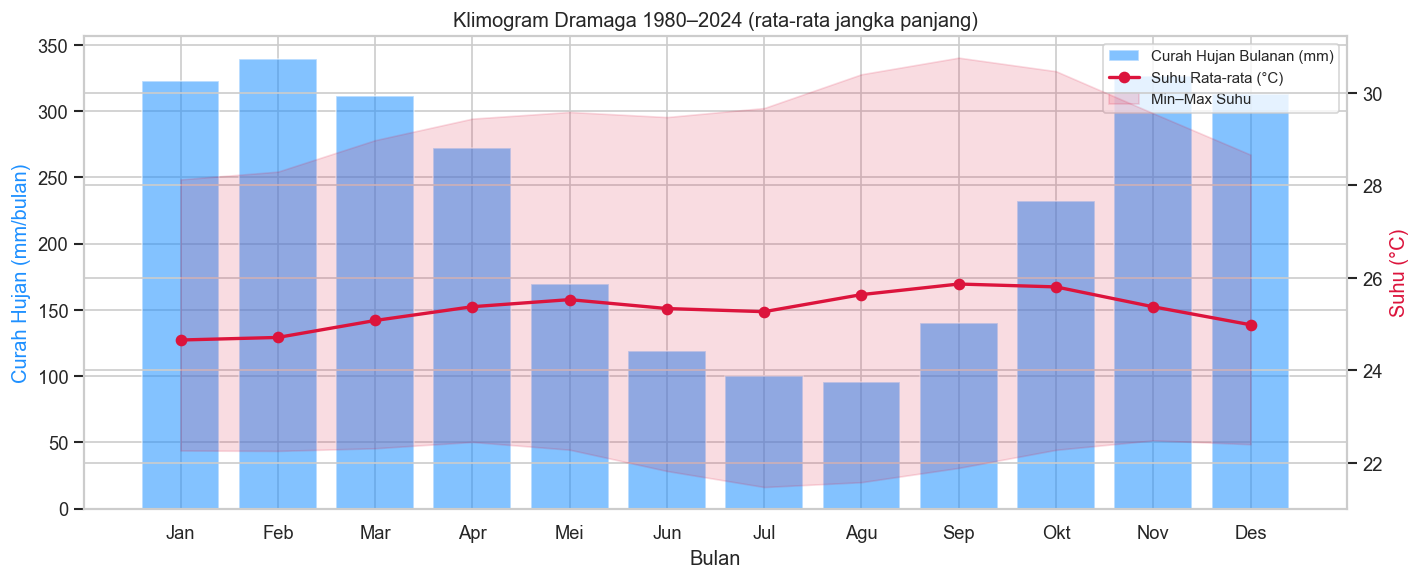

In [14]:
# Klimogram: rata-rata suhu & curah hujan bulanan
clim = df.groupby('month').agg(
    precip_mean=('precipitation_sum', 'mean'),
    temp_mean=('temperature_2m_mean', 'mean'),
    temp_max=('temperature_2m_max', 'mean'),
    temp_min=('temperature_2m_min', 'mean'),
    rh_mean=('relative_humidity_2m_mean', 'mean'),
).reindex(range(1, 13))
clim.index = month_labels

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(clim.index, clim['precip_mean'] * 30, color='dodgerblue', alpha=0.55, label='Curah Hujan Bulanan (mm)')
ax2.plot(clim.index, clim['temp_mean'], 'o-', color='crimson', lw=2, label='Suhu Rata-rata (°C)')
ax2.fill_between(clim.index, clim['temp_min'], clim['temp_max'], alpha=0.15, color='crimson', label='Min–Max Suhu')

ax1.set_ylabel('Curah Hujan (mm/bulan)', color='dodgerblue')
ax2.set_ylabel('Suhu (°C)', color='crimson')
ax1.set_xlabel('Bulan')
ax1.set_title('Klimogram Dramaga 1980–2024 (rata-rata jangka panjang)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Heatmap Korelasi Antar Variabel

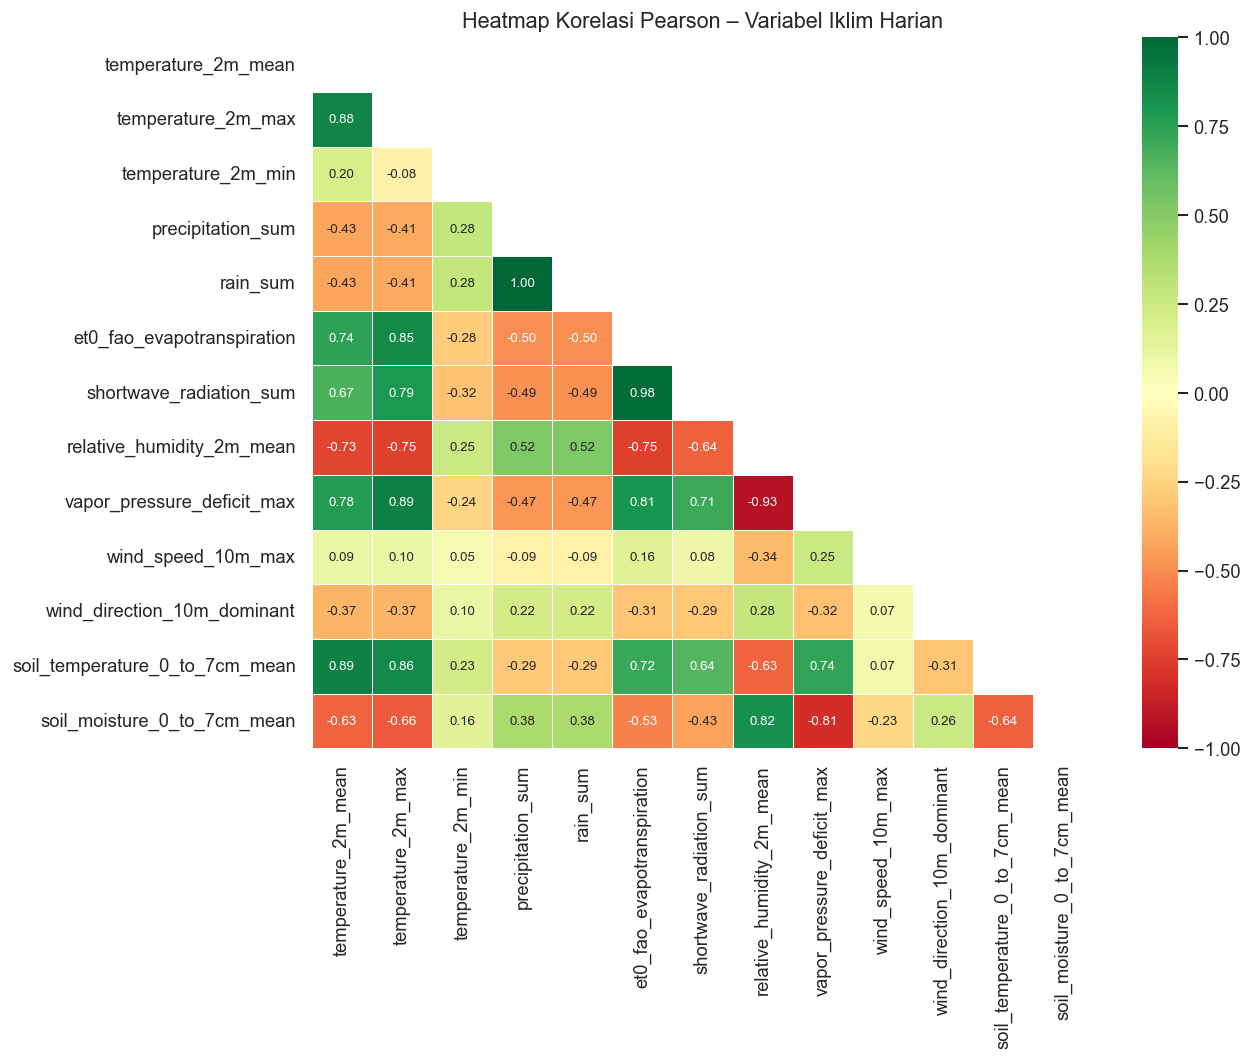

In [15]:
corr = df[cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax,
)
ax.set_title('Heatmap Korelasi Pearson – Variabel Iklim Harian', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Korelasi yang paling kuat (|r| > 0.6)
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'r']
corr_pairs['abs_r'] = corr_pairs['r'].abs()
corr_pairs.sort_values('abs_r', ascending=False).query('abs_r > 0.6').reset_index(drop=True)

,var1,var2,r,abs_r
0,rain_sum,precipitation_sum,1.000000,1.000000
1,shortwave_radiation_sum,et0_fao_evapotranspiration,0.981717,0.981717
2,vapor_pressure_deficit_max,relative_humidity_2m_mean,-0.927936,0.927936
3,vapor_pressure_deficit_max,temperature_2m_max,0.891272,0.891272
4,soil_temperature_0_to_7cm_mean,temperature_2m_mean,0.885527,0.885527
5,temperature_2m_max,temperature_2m_mean,0.875858,0.875858
6,soil_temperature_0_to_7cm_mean,temperature_2m_max,0.856801,0.856801
7,et0_fao_evapotranspiration,temperature_2m_max,0.854839,0.854839
8,soil_moisture_0_to_7cm_mean,relative_humidity_2m_mean,0.821233,0.821233
9,soil_moisture_0_to_7cm_mean,vapor_pressure_deficit_max,-0.810119,0.810119


---
## 7. Visualisasi Pola El Niño

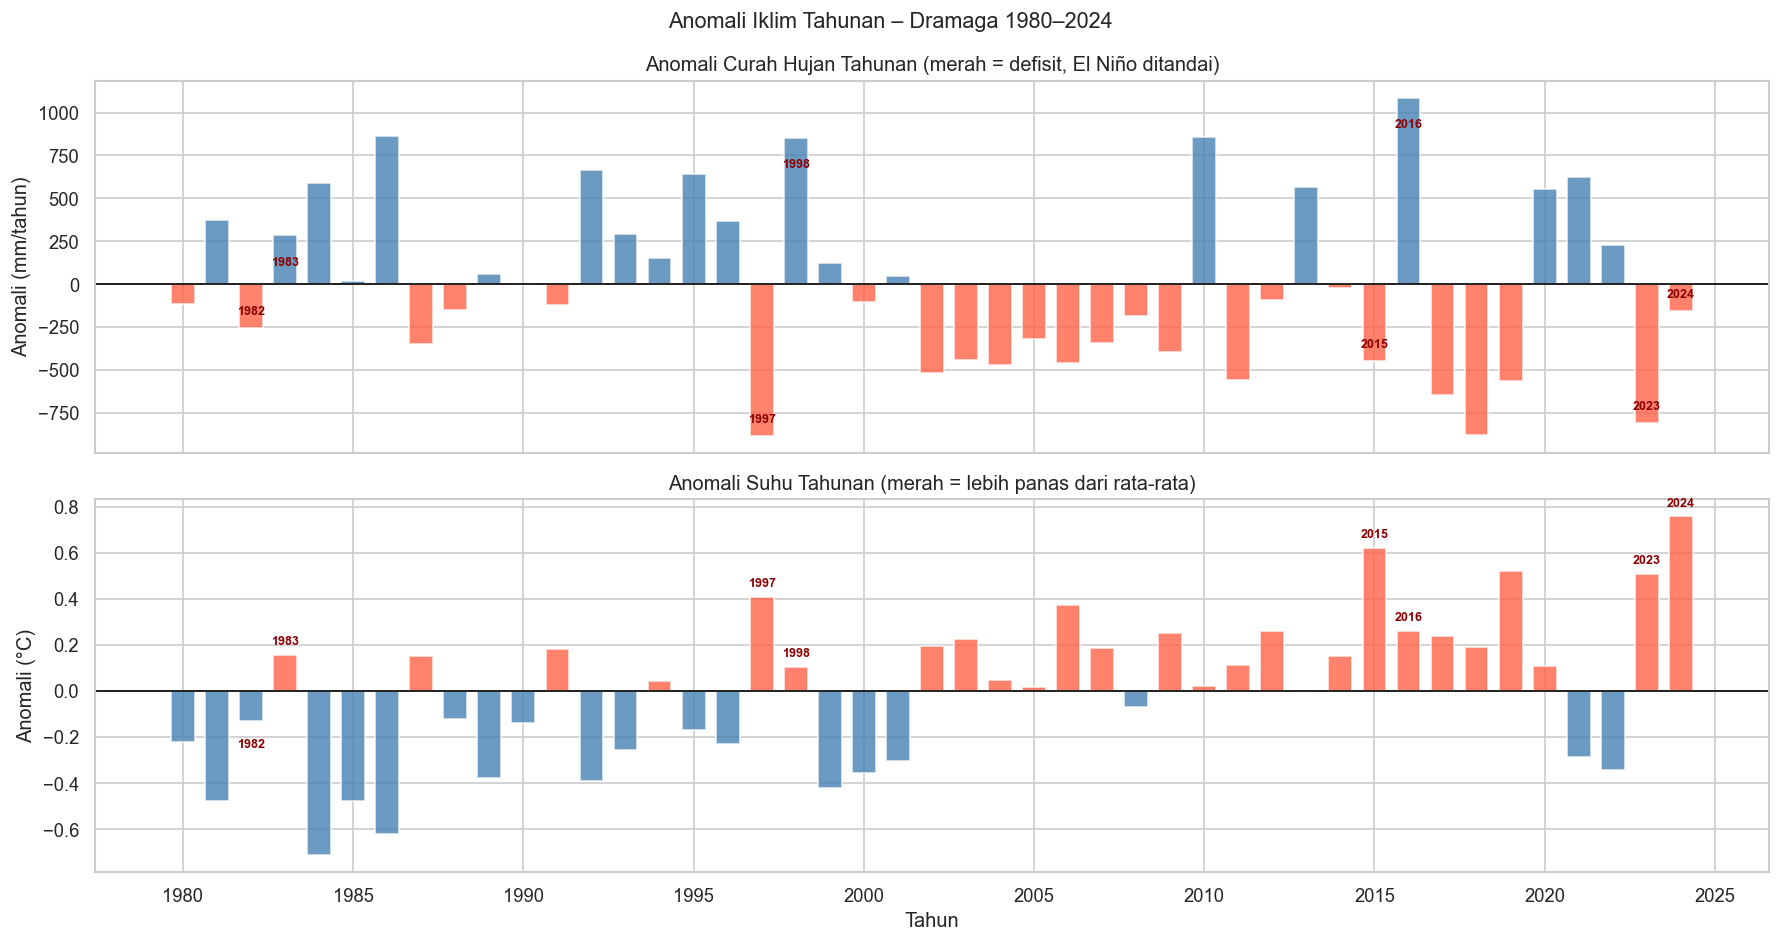

In [17]:
# Anomali curah hujan tahunan (deviasi dari rata-rata)
mean_prec = annual['precipitation_sum'].mean()
annual['precip_anomaly'] = annual['precipitation_sum'] - mean_prec

mean_temp = annual['temperature_2m_mean'].mean()
annual['temp_anomaly'] = annual['temperature_2m_mean'] - mean_temp

ENSO_YEARS_FLAT = {1982, 1983, 1997, 1998, 2015, 2016, 2023, 2024}

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Anomali Curah Hujan
ax = axes[0]
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in annual['precip_anomaly']]
ax.bar(annual.index.year, annual['precip_anomaly'], color=colors_bar, alpha=0.8, width=0.7)
ax.axhline(0, color='black', lw=1)
# Annotate El Niño years
for yr in ENSO_YEARS_FLAT:
    if yr in annual.index.year:
        val = annual.loc[annual.index.year == yr, 'precip_anomaly'].values[0]
        ax.annotate(str(yr), xy=(yr, val), xytext=(0, 8 if val < 0 else -18),
                    textcoords='offset points', ha='center', fontsize=7.5, color='darkred',
                    fontweight='bold')
ax.set_ylabel('Anomali (mm/tahun)')
ax.set_title('Anomali Curah Hujan Tahunan (merah = defisit, El Niño ditandai)')

# Anomali Suhu
ax = axes[1]
colors_bar = ['tomato' if v > 0 else 'steelblue' for v in annual['temp_anomaly']]
ax.bar(annual.index.year, annual['temp_anomaly'], color=colors_bar, alpha=0.8, width=0.7)
ax.axhline(0, color='black', lw=1)
for yr in ENSO_YEARS_FLAT:
    if yr in annual.index.year:
        val = annual.loc[annual.index.year == yr, 'temp_anomaly'].values[0]
        ax.annotate(str(yr), xy=(yr, val), xytext=(0, -16 if val < 0 else 6),
                    textcoords='offset points', ha='center', fontsize=7.5, color='darkred',
                    fontweight='bold')
ax.set_ylabel('Anomali (°C)')
ax.set_title('Anomali Suhu Tahunan (merah = lebih panas dari rata-rata)')
ax.set_xlabel('Tahun')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

fig.suptitle('Anomali Iklim Tahunan – Dramaga 1980–2024', fontsize=13)
plt.tight_layout()
plt.show()

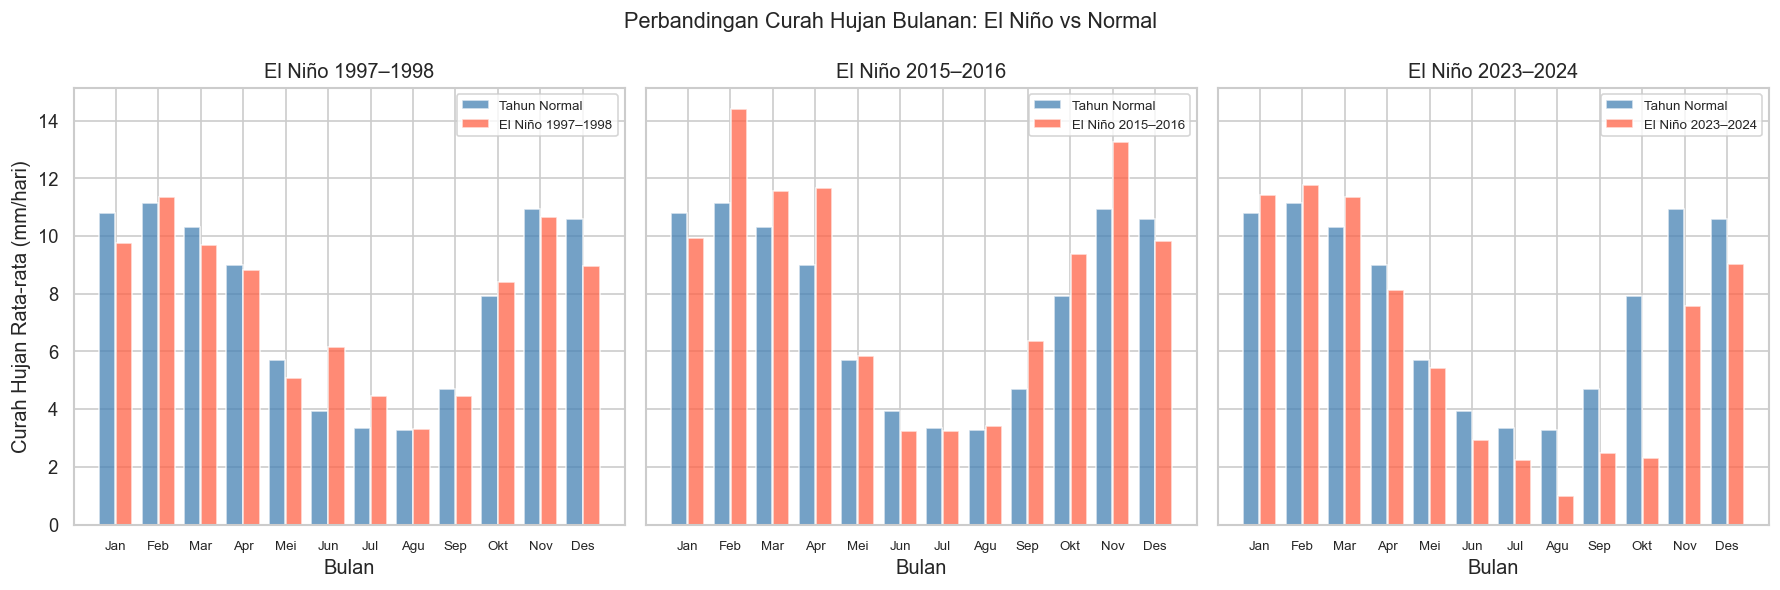

In [18]:
# Profil bulanan El Niño vs Normal – curah hujan
ENSO_YRS = [1997, 2015, 2023]
normal_years = [y for y in df['year'].unique() if y not in {y for y0 in ENSO_YRS for y in [y0, y0+1]}]

normal_monthly = (df[df['year'].isin(normal_years)]
                  .groupby('month')['precipitation_sum']
                  .mean())

fig, axes = plt.subplots(1, len(ENSO_YRS), figsize=(15, 5), sharey=True)

for ax, yr in zip(axes, ENSO_YRS):
    enso_monthly = (df[df['year'].isin([yr, yr + 1])]
                    .groupby('month')['precipitation_sum']
                    .mean())
    x = np.arange(1, 13)
    ax.bar(x - 0.2, normal_monthly.values, width=0.38, label='Tahun Normal', color='steelblue', alpha=0.75)
    ax.bar(x + 0.2, enso_monthly.values, width=0.38, label=f'El Niño {yr}–{yr+1}', color='tomato', alpha=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_title(f'El Niño {yr}–{yr+1}')
    ax.set_xlabel('Bulan')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Curah Hujan Rata-rata (mm/hari)')
fig.suptitle('Perbandingan Curah Hujan Bulanan: El Niño vs Normal', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_940126/1496331964.py:24: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


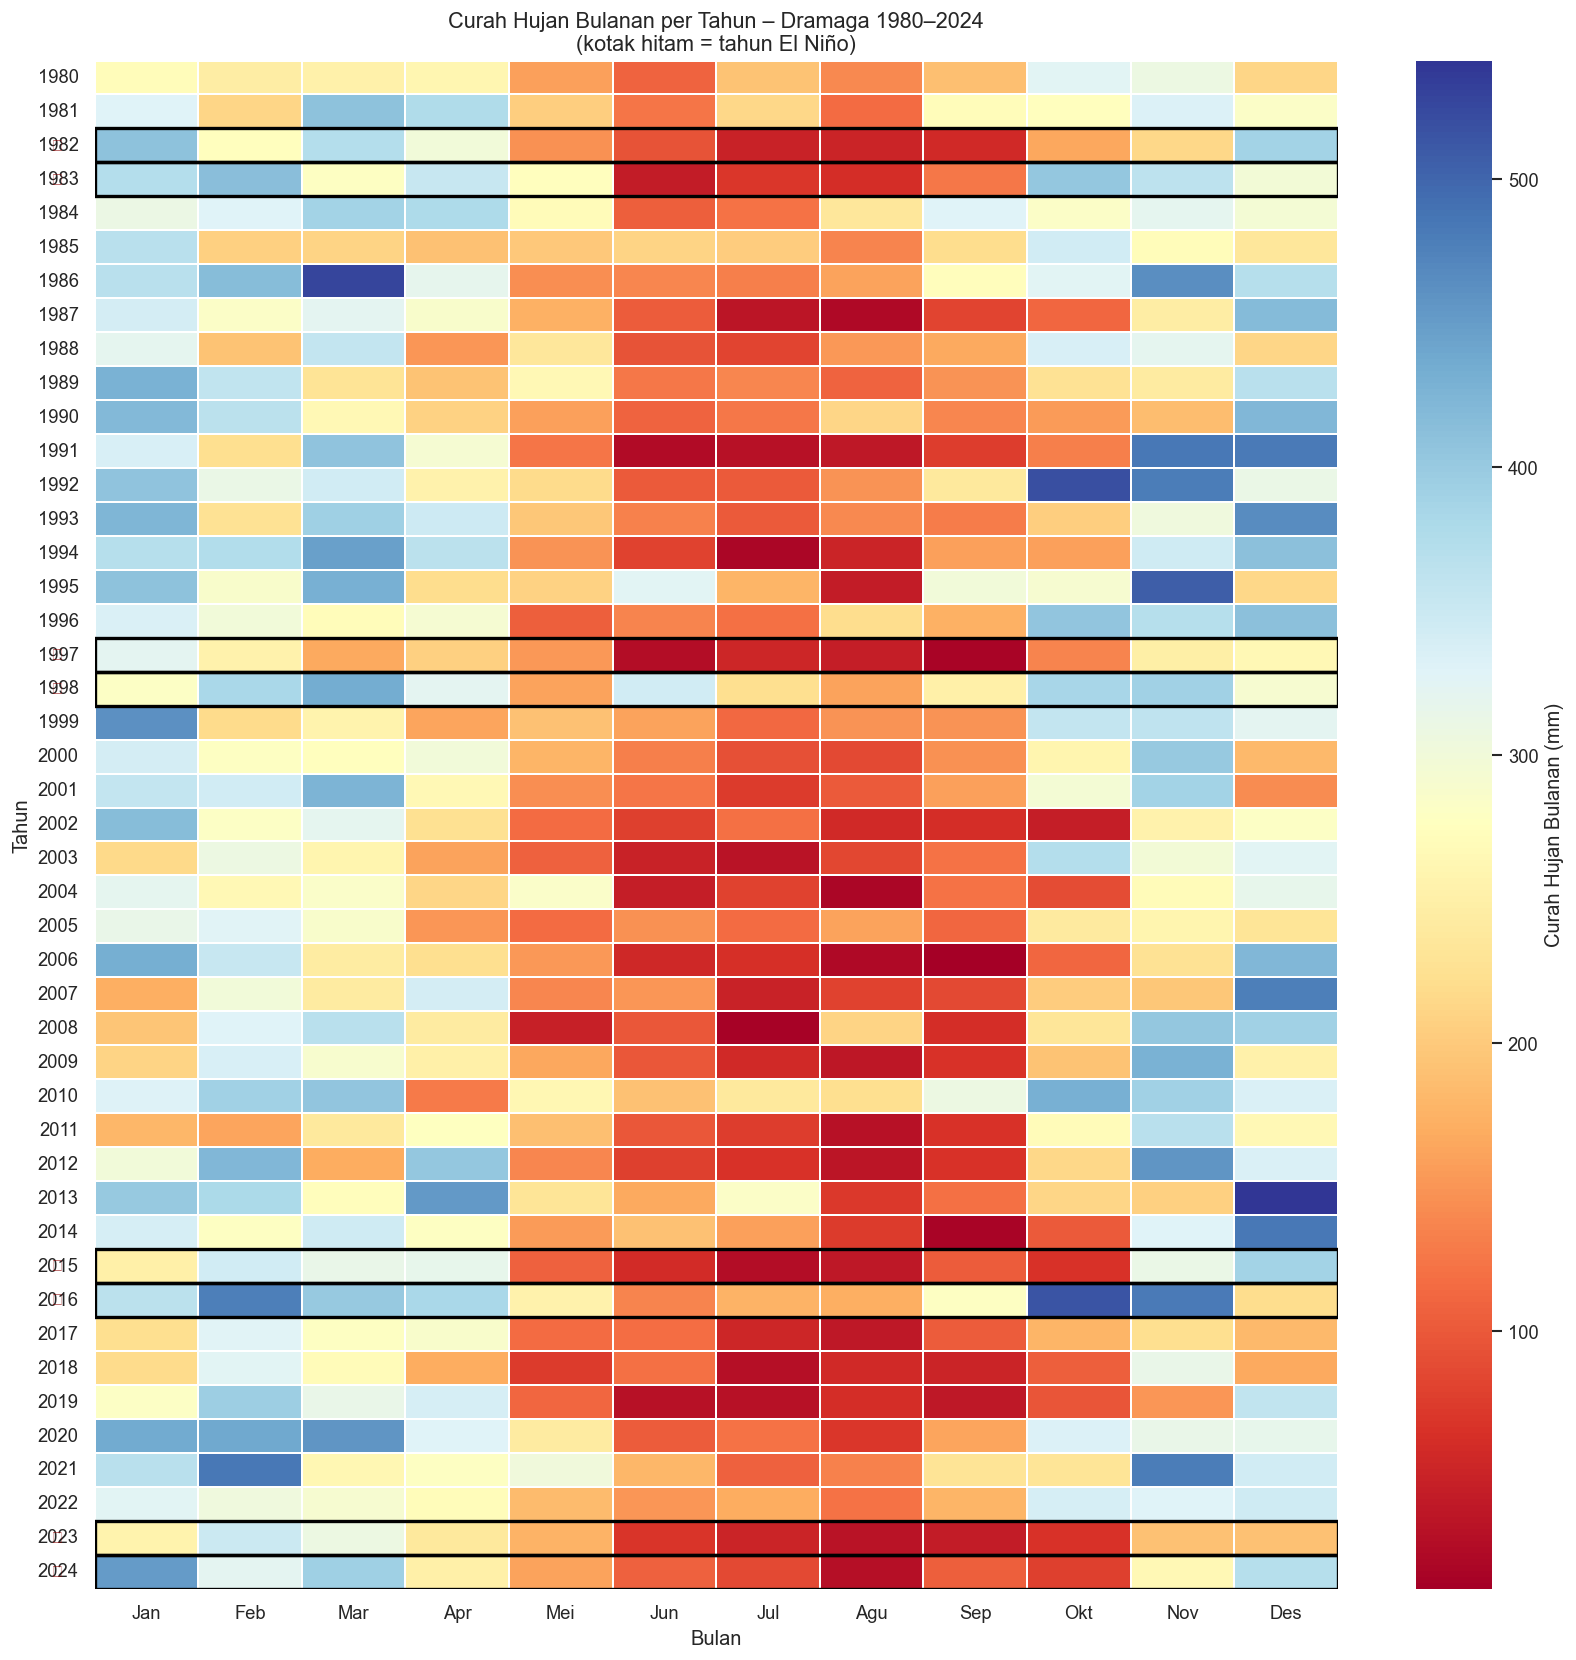

In [19]:
# Heatmap curah hujan bulanan per tahun (calendar heatmap)
pivot = df.pivot_table(index='year', columns='month', values='precipitation_sum', aggfunc='sum')
pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 14))
sns.heatmap(
    pivot,
    cmap='RdYlBu',
    linewidths=0.1,
    annot=False,
    ax=ax,
    cbar_kws={'label': 'Curah Hujan Bulanan (mm)'},
)
# Highlight El Niño years
for yr in [1982, 1983, 1997, 1998, 2015, 2016, 2023, 2024]:
    idx = pivot.index.get_loc(yr) if yr in pivot.index else None
    if idx is not None:
        ax.add_patch(plt.Rectangle((0, idx), 12, 1, fill=False, edgecolor='black', lw=2))
        ax.text(-0.3, idx + 0.5, '▶', ha='right', va='center', fontsize=10, color='darkred')

ax.set_title('Curah Hujan Bulanan per Tahun – Dramaga 1980–2024\n(kotak hitam = tahun El Niño)', fontsize=13)
ax.set_ylabel('Tahun')
ax.set_xlabel('Bulan')
plt.tight_layout()
plt.show()

---
## 8. Ringkasan Statistik Kelompok El Niño vs Normal

In [20]:
df['is_enso'] = df['year'].isin({y for y0 in ENSO_YRS for y in [y0, y0+1]})

summary = df.groupby('is_enso')[[
    'precipitation_sum', 'temperature_2m_mean',
    'relative_humidity_2m_mean', 'et0_fao_evapotranspiration',
    'soil_moisture_0_to_7cm_mean'
]].mean().T
summary.columns = ['Tahun Normal', 'Tahun El Niño']
summary['Selisih (El Niño - Normal)'] = summary['Tahun El Niño'] - summary['Tahun Normal']
summary['Perubahan (%)'] = (summary['Selisih (El Niño - Normal)'] / summary['Tahun Normal'] * 100).round(2)
summary.round(4)

,Tahun Normal,Tahun El Niño,Selisih (El Niño - Normal),Perubahan (%)
precipitation_sum,7.6207,7.4345,-0.1862,-2.44
temperature_2m_mean,25.2363,25.7484,0.5121,2.03
relative_humidity_2m_mean,85.7317,83.5358,-2.1959,-2.56
et0_fao_evapotranspiration,3.5773,3.7409,0.1636,4.57
soil_moisture_0_to_7cm_mean,0.4513,0.4300,-0.0213,-4.72


---
## 9. Simpulan EDA

| Aspek | Temuan |
|---|---|
| **Missing value** | Perlu dicek dari output sel di atas |
| **Tren suhu** | Peningkatan positif (°C/dekade) — lihat output sel time series |
| **Musiman** | Musim hujan Nov–Mar, musim kering Jun–Sep |
| **El Niño** | Defisit curah hujan signifikan pada 1997–98, 2015–16, 2023–24 |
| **Korelasi** | Suhu berkorelasi tinggi dengan radiasi & ET₀; curah hujan berkorelasi negatif dengan suhu |

> Langkah selanjutnya: **Checkpoint 3** – Perhitungan SPEI menggunakan distribusi log-logistik pada data P − ET₀.